In [1]:
import os
import shutil

# --- CẤU HÌNH ĐƯỜNG DẪN ---
work_dir = '/kaggle/working/training_environment'
base_input = '/kaggle/input/datasets/nddttt/en-vi-translation/EN VI Translate System/training_environment'

# 1. Dọn dẹp sạch sẽ nhà mới
os.chdir('/kaggle/working')
if os.path.exists(work_dir):
    shutil.rmtree(work_dir)
os.makedirs(work_dir)

# 2. Sao chép cẩn thận từng thư mục bằng Python (Kéo nguyên thư mục scripts)
folders_to_copy = ['models', 'utils', 'scripts', 'checkpoints','report','notebooks']
for folder in folders_to_copy:
    src = os.path.join(base_input, folder)
    dst = os.path.join(work_dir, folder)
    if os.path.exists(src):
        shutil.copytree(src, dst)
        print(f"Đã copy thành công: {folder}")
    else:
        print(f"CẢNH BÁO: Không tìm thấy thư mục {folder} trong kho input!")

# Sao chép file config.yaml
config_src = os.path.join(base_input, 'config.yaml')
if os.path.exists(config_src):
    shutil.copy2(config_src, work_dir)
    print("Đã copy thành công: config.yaml")

# 3. Tạo đường dẫn ảo (Symlink) cho thư mục data nặng
data_src = os.path.join(base_input, 'data')
data_dst = os.path.join(work_dir, 'data')
if os.path.exists(data_src):
    os.symlink(data_src, data_dst)
    print("Đã tạo đường dẫn ảo thành công cho: data")

# 4. Bước vào thư mục gốc của dự án
os.chdir(f'{work_dir}/notebooks')


Đã copy thành công: models
Đã copy thành công: utils
Đã copy thành công: scripts
Đã copy thành công: checkpoints
Đã copy thành công: report
Đã copy thành công: notebooks
Đã copy thành công: config.yaml
Đã tạo đường dẫn ảo thành công cho: data


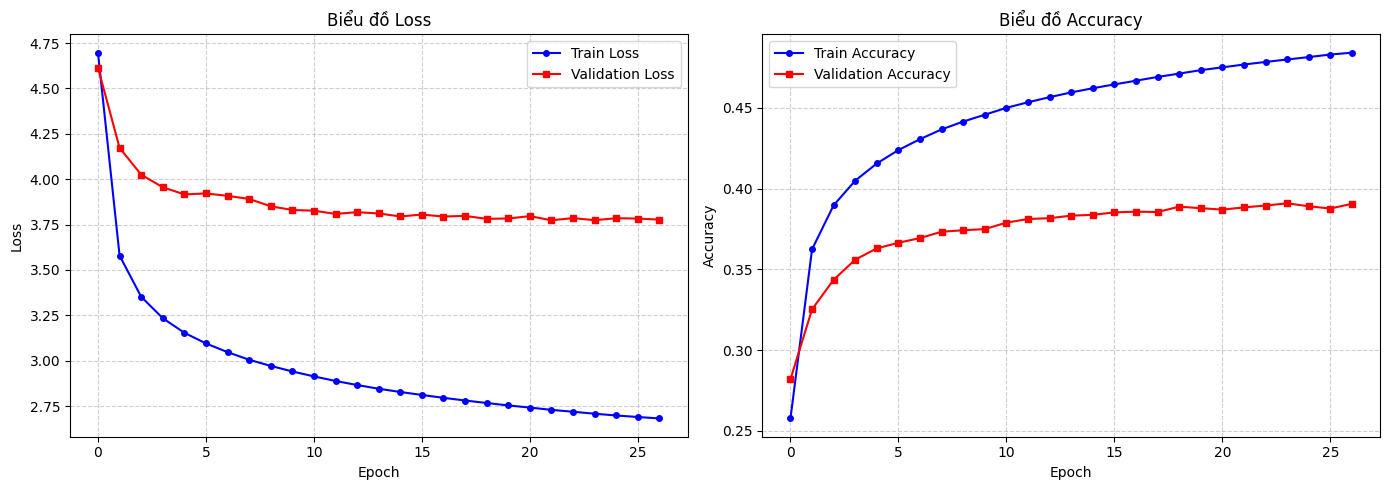

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


file_path = '../report/training_history.csv'

try:
    history = pd.read_json(file_path)
    
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    epochs = range(len(history))
    plt.plot(epochs, history['loss'], label='Train Loss', color='blue', marker='o', markersize=4)
    if 'val_loss' in history.columns:
        plt.plot(epochs, history['val_loss'], label='Validation Loss', color='red', marker='s', markersize=4)
    
    plt.title('Biểu đồ Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    acc_col = 'masked_accuracy' if 'masked_accuracy' in history.columns else 'accuracy'
    val_acc_col = 'val_masked_accuracy' if 'val_masked_accuracy' in history.columns else 'val_accuracy'

    plt.subplot(1, 2, 2)
    if acc_col in history.columns:
        plt.plot(epochs, history[acc_col], label='Train Accuracy', color='blue', marker='o', markersize=4)
    if val_acc_col in history.columns:
        plt.plot(epochs, history[val_acc_col], label='Validation Accuracy', color='red', marker='s', markersize=4)
    
    plt.title('Biểu đồ Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Không tìm thấy file tại: {file_path}")

In [3]:
import tensorflow as tf
import yaml
import sentencepiece as spm
import nltk
from nltk.translate.bleu_score import corpus_bleu
import sys

sys.path.append('../')
from models.transformer import Transformer
from utils.dataset_pipeline import TranslationDataset

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

2026-06-24 10:21:01.443432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782296461.667409      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782296461.744354      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782296462.295367      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782296462.295407      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782296462.295410      58 computation_placer.cc:177] computation placer alr

In [4]:
with open('../config.yaml','r',encoding='utf-8') as f:
    config=yaml.safe_load(f)
    
EN_SPM_PATH = '../data/tokenizer/spm_en.model'
VI_SPM_PATH = '../data/tokenizer/spm_vi.model'
TEST_TFRECORD = '../data/test.tfrecord'

sp_en=spm.SentencePieceProcessor(model_file=EN_SPM_PATH)
sp_vi=spm.SentencePieceProcessor(model_file=VI_SPM_PATH)

dataset_builder=TranslationDataset(
    max_length=config['MAX_LENGTH'],
    batch_size=config['BATCH_SIZE']
)

test_ds=dataset_builder.create_dataset(TEST_TFRECORD)

model = Transformer(
    num_layers=config["NUM_LAYERS"],
    num_heads=config["NUM_HEADS"],
    d_model=config["D_MODEL"],
    dff=config["DFF"],
    input_vocab_size=sp_en.get_piece_size(),
    tgt_vocab_size=sp_vi.get_piece_size()
)

for (en_batch, vi_inp_batch), vi_real_batch in test_ds.take(1):
    _ = model((en_batch, vi_inp_batch), training=False)
    
model.load_weights('../checkpoints/transformer_best_model.weights.h5')

I0000 00:00:1782296477.865063      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782296477.870835      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'multi_head_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support ma

In [5]:
from tqdm import tqdm

PAD_ID=0
BOS_ID=2
EOS_ID=3

@tf.function(input_signature=[tf.TensorSpec(shape=[None], dtype=tf.int32)])
def generate_token_ids(input_tensor):
    mask = tf.math.not_equal(input_tensor, PAD_ID)
    clean_tensor = tf.boolean_mask(input_tensor, mask)
    encoder_input = tf.expand_dims(clean_tensor, 0)
    
    decoder_input = [BOS_ID]
    output = tf.expand_dims(decoder_input, 0)
    
    for i in tf.range(config['MAX_LENGTH']):
        tf.autograph.experimental.set_loop_options(
            shape_invariants=[(output, tf.TensorShape([1, None]))]
        )
        
        predictions = model((encoder_input, output), training=False)
        predictions = predictions[:, -1:, :]
        predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)
        
        if predicted_id[0, 0] == EOS_ID:
            break
        
        output = tf.concat([output, predicted_id], axis=-1)
    
    return tf.squeeze(output, axis=0)[1:]

def translate_tensor(input_tensor):
    input_tensor_int32 = tf.cast(input_tensor, tf.int32)
    result_tensor = generate_token_ids(input_tensor_int32)
    result_ids = result_tensor.numpy().tolist()
    return sp_vi.DecodeIds(result_ids)

def evaluate(limit=None):
    hypotheses=[]
    references=[]
    
    dataset_to_eval = test_ds.take(limit) if limit else test_ds
    
    for (en_batch,vi_inp_batch),vi_real_batch in tqdm(dataset_to_eval,desc="Đánh giá trên tập Test"):
        batch_size_current=len(en_batch)
        
        for i in range(batch_size_current):
            vi_real_ids=vi_real_batch[i].numpy().tolist()
            vi_ids=[t for t in vi_real_ids if t not in [PAD_ID,EOS_ID,BOS_ID]]
            vi_s=sp_vi.decode(vi_ids)
            
            if not vi_s.strip():
                continue
            
            pred=translate_tensor(en_batch[i])
            
            hypotheses.append(pred)
            references.append(vi_s)
            
    ref_tokens=[[nltk.word_tokenize(ref.lower())] for ref in references]
    hyp_tokens=[nltk.word_tokenize(hyp.lower()) for hyp in hypotheses]
    
    bleu1=corpus_bleu(ref_tokens,hyp_tokens,weights=(1.0,0.0,0.0,0.0))
    bleu2=corpus_bleu(ref_tokens,hyp_tokens,weights=(0.5,0.5,0.0,0.0))
    bleu4=corpus_bleu(ref_tokens,hyp_tokens,weights=(0.25,0.25,0.25,0.25))

    print(f"Tổng số mẫu đánh giá : {len(hypotheses)} câu")
    print(f"BLEU-1 Score         : {bleu1*100:.2f} / 100")
    print(f"BLEU-2 Score         : {bleu2*100:.2f} / 100")
    print(f"BLEU-4 Score (Chuẩn) : {bleu4*100:.2f} / 100")

In [6]:
evaluate(limit=1000)

Đánh giá trên tập Test: 293it [1:19:05, 16.20s/it]


Tổng số mẫu đánh giá : 18583 câu
BLEU-1 Score         : 26.14 / 100
BLEU-2 Score         : 11.75 / 100
BLEU-4 Score (Chuẩn) : 3.18 / 100
